In [16]:
import os
import numpy as np
import pandas as pd 
import torch
import numpy.ma as ma
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.stats import pearsonr
from torch.utils.data import TensorDataset, DataLoader

from models import NeuronLSTM

# ── Config ────────────────────────────────────────────────────────────────────
lstm_dir     = "./outputs/lstm"          # single-neuron LSTM output dir
models_dir   = os.path.join(lstm_dir, "models")
base         = "./outputs/glm_input_data/"
split_path   = "test_indices_by_session.npy"

R2_THRESHOLD = 0.1    # only include neurons whose test r² meets this
hidden_size  = 64
num_layers   = 1
window       = 10
num_neurons  = 77
batch_size   = 2048

action_enc_cols = [
    'frame_raw_500msMedian',
    'frame_YawPitch_abs_vel_sum_500msMedian',
    'upcoming_choice',
    'reward_window',
    'frame_raw_abs_acc_500msMedian',
    'frame_YawPitch_abs_acc_sum_500msMedian',
    'forward_vs_rotation_corr',
    'head_angle',
    'head_angle_vel',
    'movement_energy_smooth5',
    'lick_detected',
]
input_size = len(action_enc_cols)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [17]:
# ── Load data ─────────────────────────────────────────────────────────────────
beh_vals = np.load(os.path.join(base, 'behavior_glm_input.npy'), allow_pickle=True)
beh_idx  = np.load(os.path.join(base, 'behavior_glm_input_index.npy'), allow_pickle=True)
beh_cols = np.load(os.path.join(base, 'behavior_glm_input_columns.npy'), allow_pickle=True)
spk_vals = np.load(os.path.join(base, 'fr_full.npy'))
spk_idx  = np.load(os.path.join(base, 'fr_full_index.npy'), allow_pickle=True)
spk_cols = np.load(os.path.join(base, 'fr_full_columns.npy'), allow_pickle=True)

behavior_glm_loaded = pd.DataFrame(beh_vals, index=pd.Index(beh_idx), columns=beh_cols)
spikes_loaded       = pd.DataFrame(spk_vals, index=pd.Index(spk_idx),  columns=spk_cols)

spikes_loaded.index = pd.MultiIndex.from_tuples(
    spikes_loaded.index.map(lambda t: (t[0], t[1] // 40000 - 1))
)
spikes_unique_trials = set(idx[0] for idx in spikes_loaded.index)
behavior_glm_loaded  = behavior_glm_loaded[
    behavior_glm_loaded.index.map(lambda t: t[0] in spikes_unique_trials)
]
non_nan_rows        = behavior_glm_loaded.index[~behavior_glm_loaded.isna().any(axis=1)]
behavior_glm_loaded = behavior_glm_loaded.loc[non_nan_rows]
spikes_loaded       = spikes_loaded.loc[non_nan_rows]
behavior_glm_loaded = behavior_glm_loaded.drop('track_zone', axis=1)

session_ids  = behavior_glm_loaded.index.map(lambda x: x[0]).unique()
num_sessions = len(session_ids)
print(f'{num_sessions} sessions')

29 sessions


In [18]:
# ── Build session dataset ─────────────────────────────────────────────────────
session_dataset_singles = {}

for session_id in session_ids:
    session_mask   = behavior_glm_loaded.index.map(lambda x: x[0]) == session_id
    beh            = behavior_glm_loaded[session_mask].copy()
    spikes_session = spikes_loaded[session_mask].copy()

    for col in action_enc_cols:
        if col in beh.columns:
            beh[col] = beh[col].astype(float)
            beh[col] = (beh[col] - beh[col].mean()) / (beh[col].std() + 1e-8)

    spikes_session = spikes_session.astype(float)
    for col in spikes_session.columns:
        spikes_session[col] = (
            (spikes_session[col] - spikes_session[col].mean())
            / (spikes_session[col].std() + 1e-8)
        )

    data_by_trial, labels_by_trial = {}, {}
    for trial_id in beh['trial_id'].unique():
        m = beh['trial_id'] == trial_id
        data_by_trial[trial_id]   = beh.loc[m, action_enc_cols].values.astype(np.float32)
        labels_by_trial[trial_id] = spikes_session.loc[m].values.astype(np.float32)

        session_dataset_singles[session_id] = {
        'data':   data_by_trial,
        'labels': labels_by_trial,
    }

test_indices_by_session = np.load(split_path, allow_pickle=True).item()
print('Dataset built.')

Dataset built.


In [19]:
# ── Load r² matrix and identify qualifying neurons per session ─────────────────
r2_matrix = np.load(os.path.join(lstm_dir, 'r2_matrix.npy'))
mask      = np.load(os.path.join(lstm_dir, 'mask.npy'))

r2_clipped = np.clip(r2_matrix, 0.0, 1.0)

qualifying = {}   # session_id -> list of neuron indices with r² >= threshold
for i, sid in enumerate(session_ids):
    q = np.where((r2_clipped[i] >= R2_THRESHOLD) & (~mask[i]))[0].tolist()
    qualifying[sid] = q

counts = [len(qualifying[sid]) for sid in session_ids]
print(f'Qualifying neurons per session (r²≥{R2_THRESHOLD}):')
for i, sid in enumerate(session_ids):
    print(f'  S{i+1:02d} {sid}: {counts[i]}')
print(f'\nTotal qualifying neuron-sessions: {sum(counts)}')

Qualifying neurons per session (r²≥0.1):
  S01 2024-11-14_16-40: 2
  S02 2024-11-15_15-48: 1
  S03 2024-11-20_17-46: 0
  S04 2024-11-21_17-22: 0
  S05 2024-11-25_16-25: 0
  S06 2024-11-26_16-39: 2
  S07 2024-11-28_17-41: 3
  S08 2024-11-29_17-21: 0
  S09 2024-12-02_16-09: 2
  S10 2024-12-03_16-23: 3
  S11 2024-12-04_18-06: 4
  S12 2024-12-06_16-49: 5
  S13 2024-12-09_17-45: 6
  S14 2024-12-10_17-20: 5
  S15 2024-12-11_17-42: 0
  S16 2024-12-12_16-13: 5
  S17 2024-12-13_17-10: 3
  S18 2025-01-14_18-08: 4
  S19 2025-01-15_17-18: 4
  S20 2025-01-16_17-47: 5
  S21 2025-01-17_16-55: 4
  S22 2025-01-21_18-49: 2
  S23 2025-01-22_17-51: 4
  S24 2025-01-23_16-48: 3
  S25 2025-01-24_12-24: 2
  S26 2025-01-24_19-37: 2
  S27 2025-01-25_21-29: 5
  S28 2025-01-26_21-48: 5
  S29 2025-01-27_13-39: 4

Total qualifying neuron-sessions: 85


In [20]:
# ── Helper: build test windows ────────────────────────────────────────────────
def make_windows(data_dict, trial_ids, window):
    X_list = []
    for tid in trial_ids:
        if tid not in data_dict:
            continue
        data   = data_dict[tid]
        T      = len(data)
        padded = np.zeros((window - 1 + T, data.shape[1]), dtype=np.float32)
        padded[window - 1:] = data
        for t in range(T):
            X_list.append(padded[t: t + window])
    return np.stack(X_list) if X_list else None   # (N, window, F)

In [21]:
# ── Extract embeddings for each qualifying neuron ─────────────────────────────
# Result: embeddings_by_session[sid] = dict {neuron_idx: (N, hidden_size)}

embeddings_by_session = {}

for sess_idx, sid in enumerate(session_ids):
    neurons = qualifying[sid]
    if len(neurons) < 2:
        embeddings_by_session[sid] = {}
        continue

    test_trials = [int(i) for i in test_indices_by_session[sid]]
    X_test = make_windows(session_dataset_singles[sid]['data'], test_trials, window)
    if X_test is None:
        embeddings_by_session[sid] = {}
        continue

    X_t    = torch.tensor(X_test, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_t), batch_size=batch_size)

    session_embs = {}
    for nidx in neurons:
        model_path = os.path.join(models_dir, f'session_{sess_idx:02d}_neuron_{nidx:02d}.pt')
        if not os.path.exists(model_path):
            continue

        model = NeuronLSTM(input_size, hidden_size, num_layers, output_size=1).to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()

        emb_list = []
        with torch.no_grad():
            for (xb,) in loader:
                emb_list.append(model.embed(xb.to(device)).cpu().numpy())
        session_embs[nidx] = np.concatenate(emb_list, axis=0)  # (N, hidden_size)

        del model
        torch.cuda.empty_cache()

    embeddings_by_session[sid] = session_embs
    print(f'S{sess_idx+1:02d} {sid}: extracted {len(session_embs)} embeddings  '
          f'shape {list(session_embs.values())[0].shape if session_embs else "—"}')

print('Done.')

S01 2024-11-14_16-40: extracted 2 embeddings  shape (5075, 64)
S06 2024-11-26_16-39: extracted 2 embeddings  shape (5659, 64)
S07 2024-11-28_17-41: extracted 3 embeddings  shape (6933, 64)
S09 2024-12-02_16-09: extracted 2 embeddings  shape (5367, 64)
S10 2024-12-03_16-23: extracted 3 embeddings  shape (6229, 64)
S11 2024-12-04_18-06: extracted 4 embeddings  shape (5404, 64)
S12 2024-12-06_16-49: extracted 5 embeddings  shape (5491, 64)
S13 2024-12-09_17-45: extracted 6 embeddings  shape (5689, 64)
S14 2024-12-10_17-20: extracted 5 embeddings  shape (6503, 64)
S16 2024-12-12_16-13: extracted 5 embeddings  shape (4977, 64)
S17 2024-12-13_17-10: extracted 3 embeddings  shape (5885, 64)
S18 2025-01-14_18-08: extracted 4 embeddings  shape (5585, 64)
S19 2025-01-15_17-18: extracted 4 embeddings  shape (6177, 64)
S20 2025-01-16_17-47: extracted 5 embeddings  shape (6468, 64)
S21 2025-01-17_16-55: extracted 4 embeddings  shape (6880, 64)
S22 2025-01-21_18-49: extracted 2 embeddings  shape (12

In [22]:
# ── Pairwise embedding correlation within each session ────────────────────────
# For each pair of qualifying neurons (i, j) in the same session, compute
# Pearson r between their flattened embedding trajectories (N * hidden_size).
# This asks: do two neurons' LSTMs learn the same behavioral representation?

def embedding_corr(E_i, E_j):
    """Pearson r between two (N, hidden_size) embedding matrices, flattened."""
    a = E_i.flatten()
    b = E_j.flatten()
    r, _ = pearsonr(a, b)
    return r

corr_matrices  = {}   # sid -> (k, k) correlation matrix  (k = # qualifying neurons)
neuron_lists   = {}   # sid -> ordered list of neuron indices

for sid in session_ids:
    embs = embeddings_by_session[sid]
    if len(embs) < 2:
        continue

    neurons  = sorted(embs.keys())
    k        = len(neurons)
    corr_mat = np.eye(k)

    for ii in range(k):
        for jj in range(ii + 1, k):
            r = embedding_corr(embs[neurons[ii]], embs[neurons[jj]])
            corr_mat[ii, jj] = r
            corr_mat[jj, ii] = r

    corr_matrices[sid] = corr_mat
    neuron_lists[sid]  = neurons

print(f'Computed pairwise correlations for {len(corr_matrices)} sessions.')

Computed pairwise correlations for 23 sessions.


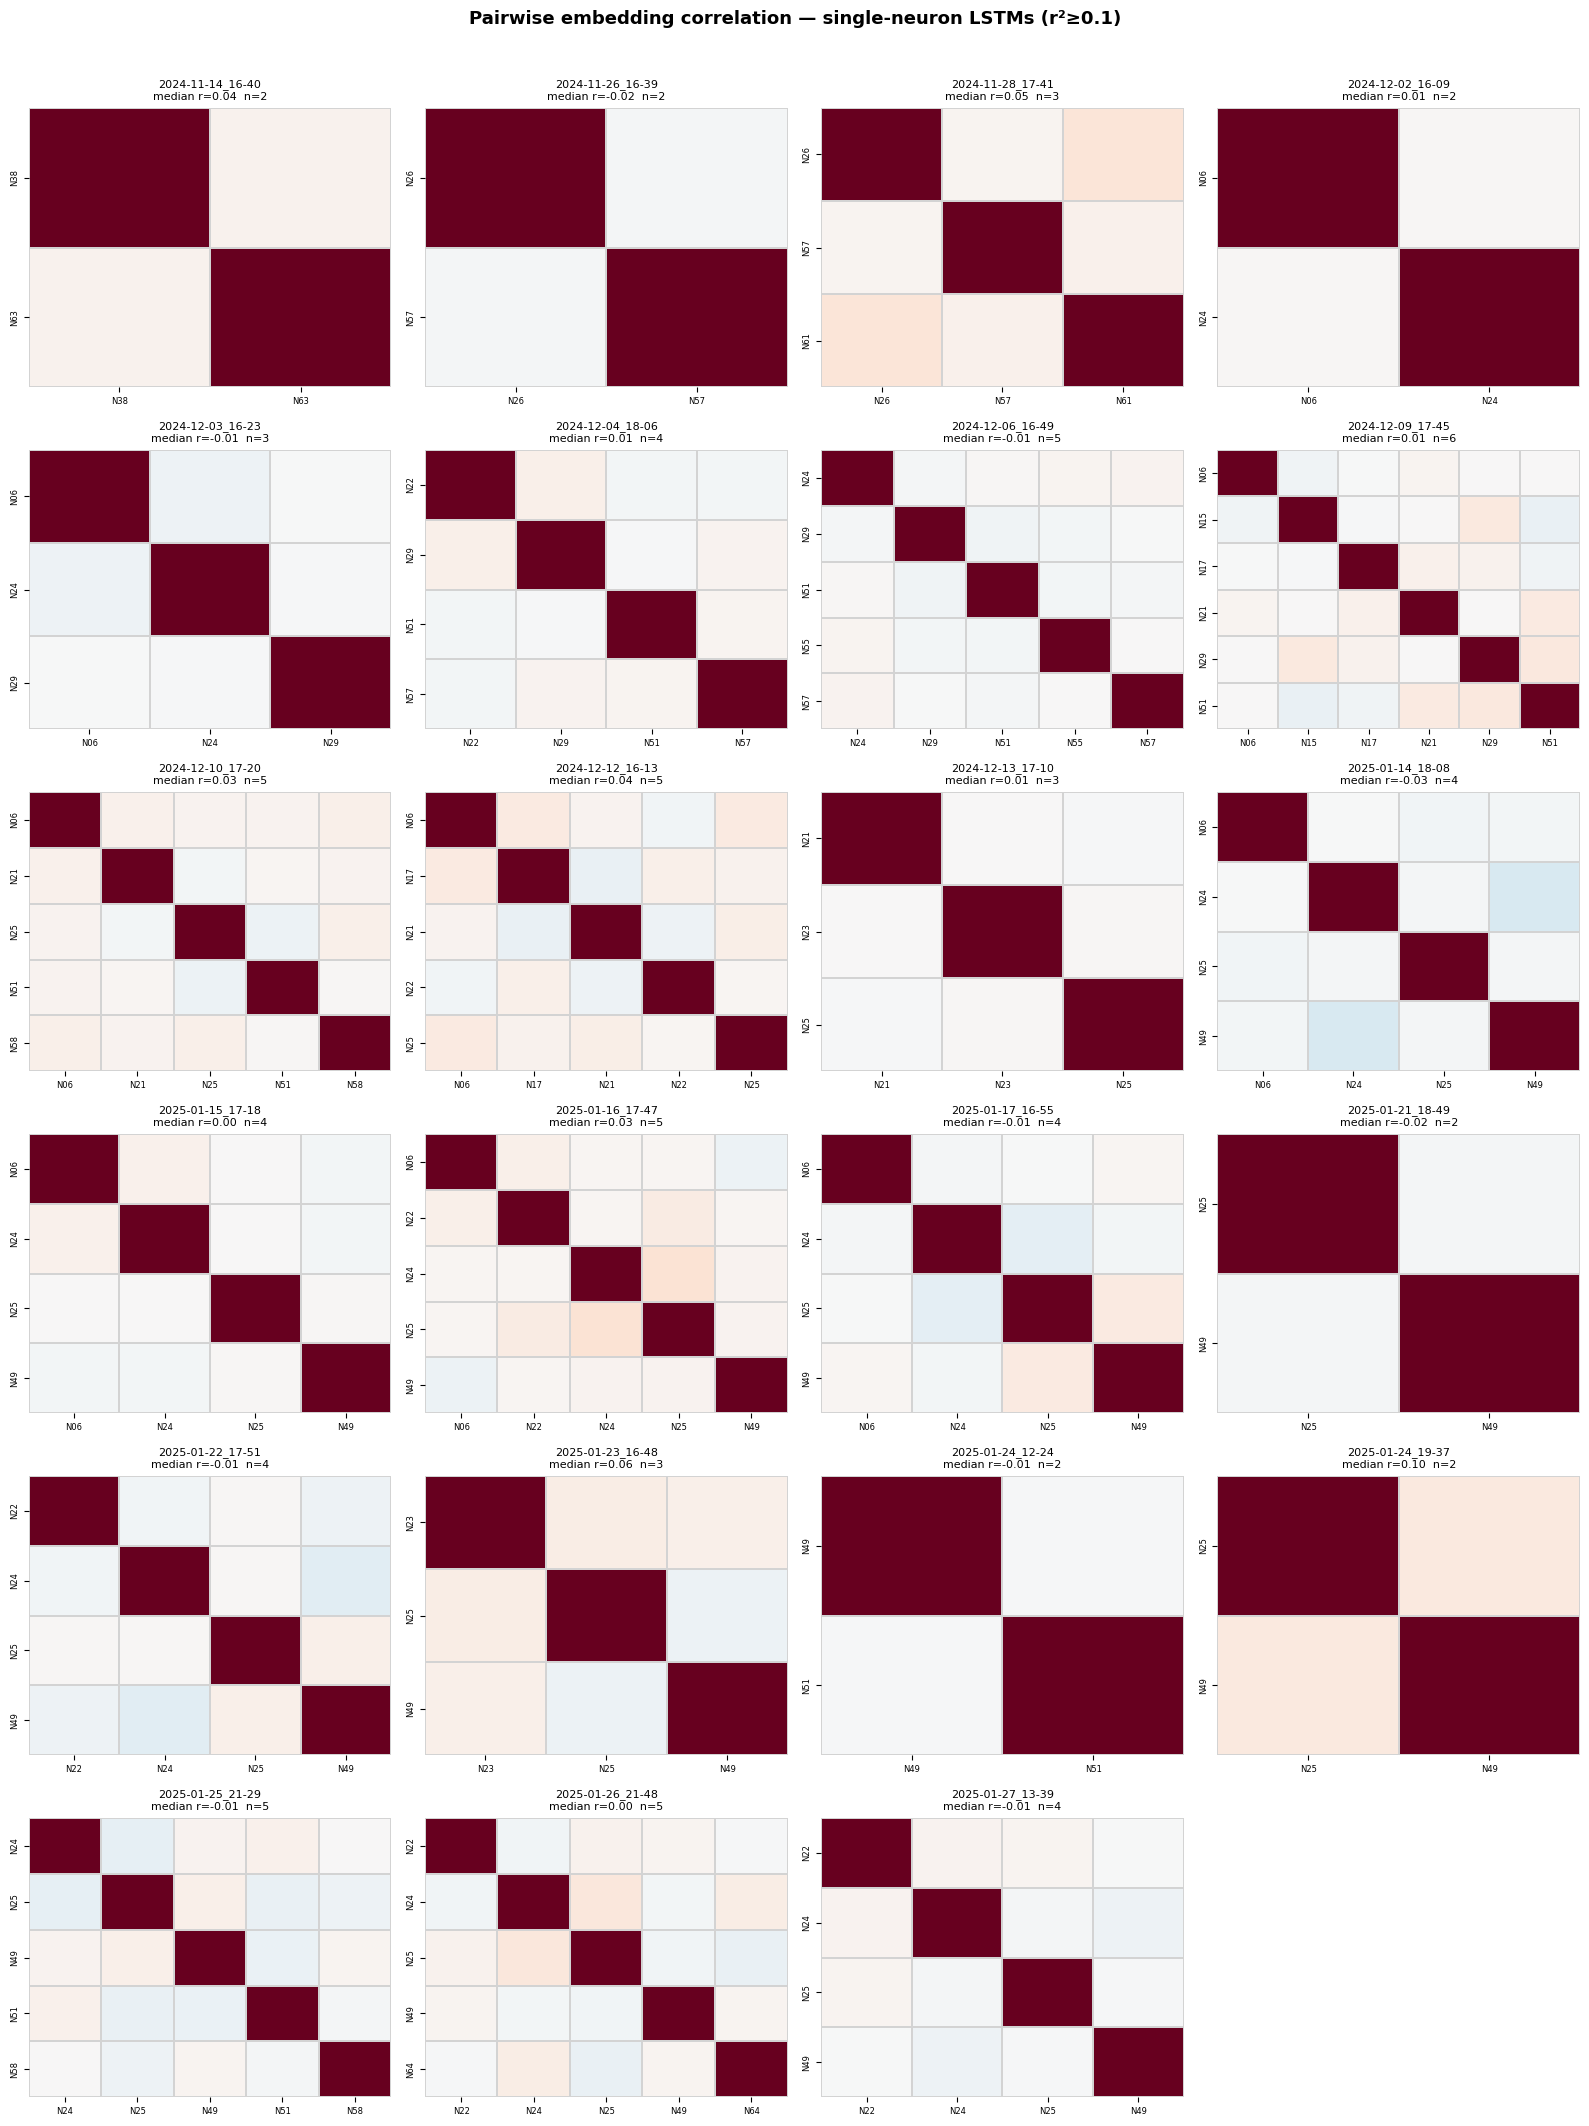

In [23]:
# ── Heatmaps of pairwise embedding correlation per session ────────────────────
sessions_to_plot = [sid for sid in session_ids if sid in corr_matrices]
ncols = 4
nrows = int(np.ceil(len(sessions_to_plot) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
axes = np.array(axes).flatten()

for ax, sid in zip(axes, sessions_to_plot):
    cmat    = corr_matrices[sid]
    neurons = neuron_lists[sid]
    labels  = [f'N{n+1:02d}' for n in neurons]
    off_diag = cmat[np.triu_indices_from(cmat, k=1)]
    median_r = np.median(off_diag)

    sns.heatmap(cmat, ax=ax, cmap='RdBu_r', vmin=-1, vmax=1,
                xticklabels=labels, yticklabels=labels,
                cbar=False, linewidths=0.3, linecolor='lightgray')
    ax.set_title(f'{sid}\nmedian r={median_r:.2f}  n={len(neurons)}',
                 fontsize=8)
    ax.tick_params(labelsize=6)

for ax in axes[len(sessions_to_plot):]:
    ax.set_visible(False)

plt.suptitle(f'Pairwise embedding correlation — single-neuron LSTMs (r²≥{R2_THRESHOLD})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

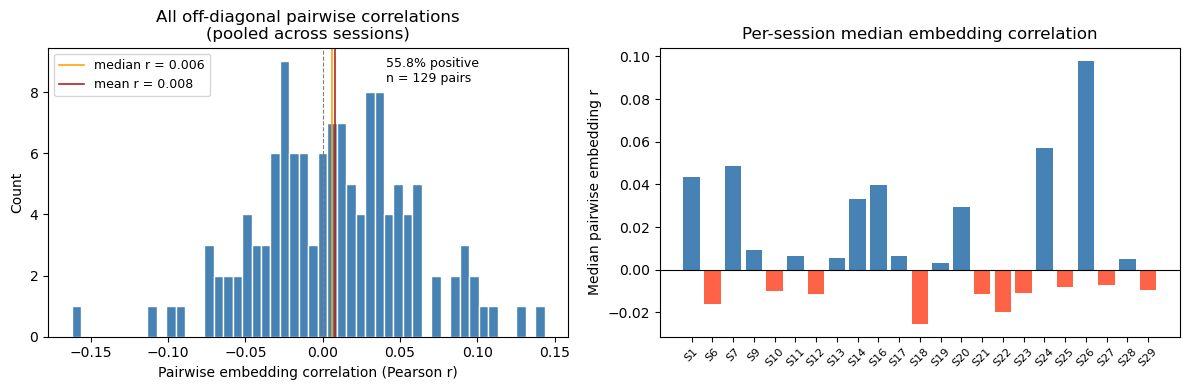

Grand mean  r : 0.0076
Grand median r: 0.0062
Std           : 0.0500
% pairs r > 0 : 55.8%


In [24]:
# ── Distribution of off-diagonal correlations across all sessions ─────────────
all_off_diag = np.concatenate([
    corr_matrices[sid][np.triu_indices_from(corr_matrices[sid], k=1)]
    for sid in corr_matrices
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# histogram
ax = axes[0]
ax.hist(all_off_diag, bins=50, color='steelblue', edgecolor='white')
ax.axvline(0,                       color='gray',     linestyle='--', linewidth=0.8)
ax.axvline(np.median(all_off_diag), color='orange',   linestyle='-',  linewidth=1.2,
           label=f'median r = {np.median(all_off_diag):.3f}')
ax.axvline(np.mean(all_off_diag),   color='firebrick',linestyle='-',  linewidth=1.2,
           label=f'mean r = {np.mean(all_off_diag):.3f}')
ax.set_xlabel('Pairwise embedding correlation (Pearson r)')
ax.set_ylabel('Count')
ax.set_title('All off-diagonal pairwise correlations\n(pooled across sessions)')
ax.legend(fontsize=9)
frac_pos = np.mean(all_off_diag > 0)
ax.annotate(f'{frac_pos*100:.1f}% positive\nn = {len(all_off_diag)} pairs',
            xy=(0.65, 0.88), xycoords='axes fraction', fontsize=9)

# per-session median
ax = axes[1]
sess_medians = [
    np.median(corr_matrices[sid][np.triu_indices_from(corr_matrices[sid], k=1)])
    for sid in session_ids if sid in corr_matrices
]
sess_labels  = [f'S{list(session_ids).index(sid)+1}'
                for sid in session_ids if sid in corr_matrices]
colors = ['steelblue' if v >= 0 else 'tomato' for v in sess_medians]
ax.bar(range(len(sess_medians)), sess_medians, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(len(sess_medians)))
ax.set_xticklabels(sess_labels, rotation=45, fontsize=8)
ax.set_ylabel('Median pairwise embedding r')
ax.set_title('Per-session median embedding correlation')

plt.tight_layout()
plt.show()

print(f'Grand mean  r : {np.mean(all_off_diag):.4f}')
print(f'Grand median r: {np.median(all_off_diag):.4f}')
print(f'Std           : {np.std(all_off_diag):.4f}')
print(f'% pairs r > 0 : {frac_pos*100:.1f}%')

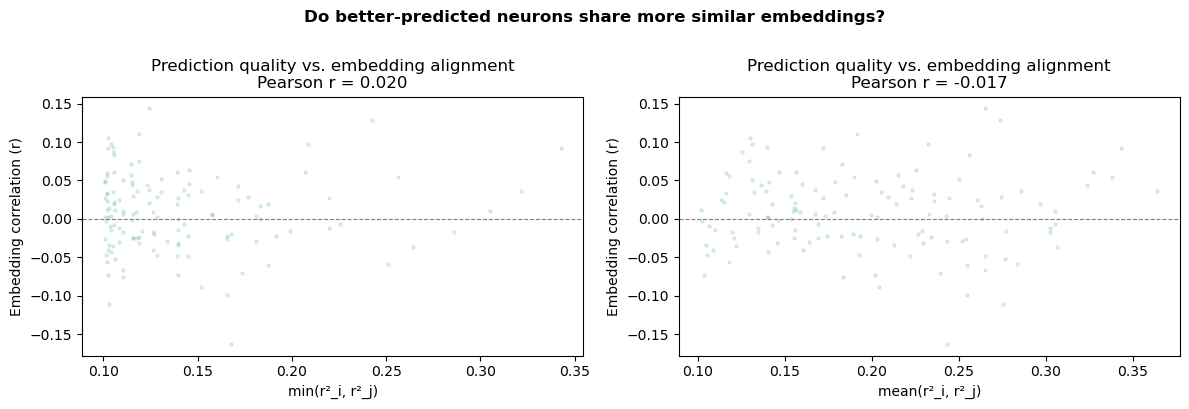

In [25]:
# ── Does higher r² predict stronger embedding alignment? ─────────────────────
# For each pair (i,j) in a session, record min(r²_i, r²_j) and the embedding corr.
pair_min_r2  = []
pair_emb_r   = []
pair_mean_r2 = []

for sess_idx, sid in enumerate(session_ids):
    if sid not in corr_matrices:
        continue
    neurons  = neuron_lists[sid]
    cmat     = corr_matrices[sid]
    sess_r2  = r2_clipped[sess_idx]

    for ii in range(len(neurons)):
        for jj in range(ii + 1, len(neurons)):
            ri = sess_r2[neurons[ii]]
            rj = sess_r2[neurons[jj]]
            pair_min_r2.append(min(ri, rj))
            pair_mean_r2.append((ri + rj) / 2)
            pair_emb_r.append(cmat[ii, jj])

pair_min_r2  = np.array(pair_min_r2)
pair_mean_r2 = np.array(pair_mean_r2)
pair_emb_r   = np.array(pair_emb_r)

r_min,  _ = pearsonr(pair_min_r2,  pair_emb_r)
r_mean, _ = pearsonr(pair_mean_r2, pair_emb_r)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, x, label, r_val in [
    (axes[0], pair_min_r2,  'min(r²_i, r²_j)',  r_min),
    (axes[1], pair_mean_r2, 'mean(r²_i, r²_j)', r_mean),
]:
    ax.scatter(x, pair_emb_r, alpha=0.12, s=5, color='teal', rasterized=True)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel(label)
    ax.set_ylabel('Embedding correlation (r)')
    ax.set_title(f'Prediction quality vs. embedding alignment\n'
                 f'Pearson r = {r_val:.3f}')

plt.suptitle('Do better-predicted neurons share more similar embeddings?',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

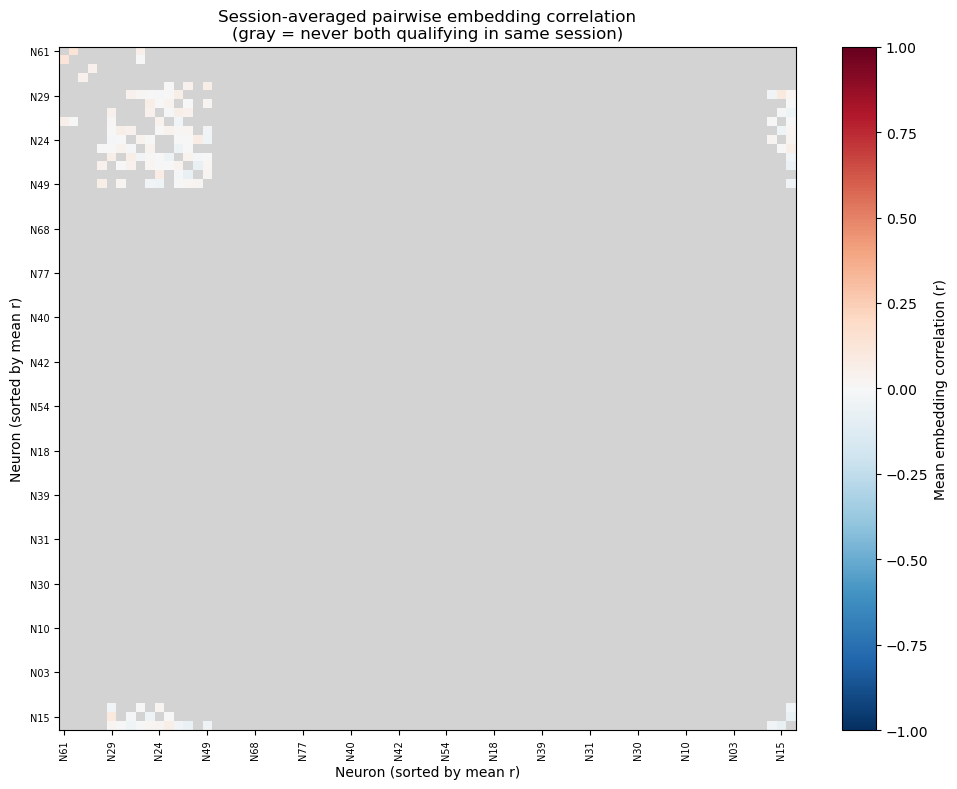

Neuron pairs with data: 60
Mean r across all pairs: 0.0110


In [26]:
# ── Average embedding correlation matrix across sessions ─────────────────────
# Align neurons by global index (77 x 77) and average over sessions.
# Cells with no data in any session are NaN.

avg_corr = np.full((num_neurons, num_neurons), np.nan)
count    = np.zeros((num_neurons, num_neurons), dtype=int)

for sid in corr_matrices:
    neurons = neuron_lists[sid]
    cmat    = corr_matrices[sid]
    for ii, ni in enumerate(neurons):
        for jj, nj in enumerate(neurons):
            if ii == jj:
                continue
            if np.isnan(avg_corr[ni, nj]):
                avg_corr[ni, nj] = 0.0
            avg_corr[ni, nj] += cmat[ii, jj]
            count[ni, nj]    += 1

with np.errstate(invalid='ignore'):
    avg_corr /= np.where(count > 0, count, np.nan)

# sort neurons by mean off-diagonal correlation (most correlated first)
mean_row = np.nanmean(avg_corr, axis=1)
order    = np.argsort(np.nan_to_num(mean_row))[::-1]
avg_sorted  = avg_corr[np.ix_(order, order)]
nan_mask    = np.isnan(avg_sorted)

fig, ax = plt.subplots(figsize=(10, 8))
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad('lightgray')
im = ax.imshow(avg_sorted, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Mean embedding correlation (r)')
ax.set_xlabel('Neuron (sorted by mean r)')
ax.set_ylabel('Neuron (sorted by mean r)')
ax.set_title('Session-averaged pairwise embedding correlation\n'
             '(gray = never both qualifying in same session)',
             fontsize=12)

n_labels = [f'N{order[i]+1:02d}' for i in range(num_neurons)]
ax.set_xticks(range(0, num_neurons, 5))
ax.set_xticklabels(n_labels[::5], rotation=90, fontsize=7)
ax.set_yticks(range(0, num_neurons, 5))
ax.set_yticklabels(n_labels[::5], fontsize=7)

plt.tight_layout()
plt.show()

valid_pairs = ~np.isnan(avg_corr)
np.fill_diagonal(valid_pairs, False)
print(f'Neuron pairs with data: {valid_pairs.sum() // 2}')
print(f'Mean r across all pairs: {np.nanmean(avg_corr[valid_pairs]):.4f}')

In [27]:
# ── Extract ground-truth firing rates on test trials ─────────────────────────
# Align labels with the same trial order used in make_windows so that
# test_labels_by_session[sid][t, nidx] matches embeddings_by_session[sid][nidx][t]

def make_labels(labels_dict, trial_ids):
    """Concatenate per-trial label arrays (T, num_neurons) in trial order."""
    y_list = []
    for tid in trial_ids:
        if tid not in labels_dict:
            continue
        y_list.append(labels_dict[tid])
    return np.concatenate(y_list, axis=0) if y_list else None   # (N, num_neurons)

test_labels_by_session = {}

for sess_idx, sid in enumerate(session_ids):
    if len(embeddings_by_session[sid]) < 2:
        continue
    test_trials = [int(i) for i in test_indices_by_session[sid]]
    Y = make_labels(session_dataset_singles[sid]['labels'], test_trials)
    test_labels_by_session[sid] = Y   # (N, all_neurons_in_session)

print(f'Test labels extracted for {len(test_labels_by_session)} sessions.')
for sid, Y in list(test_labels_by_session.items())[:3]:
    print(f'  {sid}: Y.shape = {Y.shape}')

Test labels extracted for 23 sessions.
  2024-11-14_16-40: Y.shape = (5075, 77)
  2024-11-26_16-39: Y.shape = (5659, 77)
  2024-11-28_17-41: Y.shape = (6933, 77)


In [28]:
# ── Cross-neuron probe decoding ───────────────────────────────────────────────
# For each ordered pair (source → target) of qualifying neurons in the same session:
#   X = source neuron's LSTM embedding  (N, hidden_size)
#   y = target neuron's z-scored firing rate  (N,)
#
# Three probes trained on ~80% of *trials* (random split, same scheme as the
# original train/test split), evaluated on the held-out ~20% of trials:
#   • Linear   – Ridge regression (closed-form, fast)
#   • MLP      – two-hidden-layer network (64→32→1)
#   • Shuffle  – Ridge on time-shuffled embeddings (null baseline)

from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

VAL_FRAC    = 0.2
RIDGE_ALPHA = 1.0
MLP_HIDDEN  = (64, 32)
MLP_ITER    = 300
RNG         = np.random.default_rng(42)

cross_decode = {}   # sid -> {(src_nidx, tgt_nidx): {'linear': r2, 'mlp': r2, 'shuffle': r2}}

for sess_idx, sid in enumerate(session_ids):
    embs = embeddings_by_session[sid]
    if len(embs) < 2 or sid not in test_labels_by_session:
        continue

    Y       = test_labels_by_session[sid]   # (N, num_neurons)
    neurons = sorted(embs.keys())
    N       = list(embs.values())[0].shape[0]

    # ── Random trial-based split (mirrors original train/test split) ──────────
    test_trials  = [int(i) for i in test_indices_by_session[sid]]
    data_dict    = session_dataset_singles[sid]['data']
    valid_trials = [t for t in test_trials if t in data_dict]

    # build a per-timestep trial label array (same order as make_windows)
    timestep_trial = np.array(
        [tid for tid in valid_trials for _ in range(len(data_dict[tid]))]
    )

    # randomly hold out VAL_FRAC of trials
    n_val      = max(1, int(len(valid_trials) * VAL_FRAC))
    val_trials = set(RNG.choice(valid_trials, size=n_val, replace=False).tolist())
    train_idx  = np.where(~np.isin(timestep_trial, list(val_trials)))[0]
    val_idx    = np.where( np.isin(timestep_trial, list(val_trials)))[0]

    results = {}
    for src in neurons:
        X_raw = embs[src]   # (N, 64)

        # time-shuffled copy as null baseline
        shuf_perm = RNG.permutation(N)
        X_shuf    = X_raw[shuf_perm]

        scaler   = StandardScaler().fit(X_raw[train_idx])
        X        = scaler.transform(X_raw)
        X_shuf_s = scaler.transform(X_shuf)

        X_tr, X_val   = X[train_idx],        X[val_idx]
        Xs_tr, Xs_val = X_shuf_s[train_idx], X_shuf_s[val_idx]

        for tgt in neurons:
            if tgt == src:
                continue
            y      = Y[:, tgt]
            y_tr   = y[train_idx]
            y_val  = y[val_idx]

            # --- Linear probe ---
            lin = Ridge(alpha=RIDGE_ALPHA)
            lin.fit(X_tr, y_tr)
            r2_lin = r2_score(y_val, lin.predict(X_val))

            # --- MLP probe ---
            mlp = MLPRegressor(
                hidden_layer_sizes=MLP_HIDDEN,
                activation='relu',
                max_iter=MLP_ITER,
                random_state=42,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=15,
            )
            mlp.fit(X_tr, y_tr)
            r2_mlp = r2_score(y_val, mlp.predict(X_val))

            # --- Shuffle baseline (linear only) ---
            lin_shuf = Ridge(alpha=RIDGE_ALPHA)
            lin_shuf.fit(Xs_tr, y_tr)
            r2_shuf = r2_score(y_val, lin_shuf.predict(Xs_val))

            results[(src, tgt)] = {
                'linear':  r2_lin,
                'mlp':     r2_mlp,
                'shuffle': r2_shuf,
            }

    cross_decode[sid] = results

    vals = [v['linear'] for v in results.values()]
    print(f'{sid}: {len(results)} pairs  |  '
          f'linear R² mean={np.mean(vals):.3f}  max={np.max(vals):.3f}')

print('Done.')

2024-11-14_16-40: 2 pairs  |  linear R² mean=0.371  max=0.516
2024-11-26_16-39: 2 pairs  |  linear R² mean=0.046  max=0.053
2024-11-28_17-41: 6 pairs  |  linear R² mean=0.111  max=0.214
2024-12-02_16-09: 2 pairs  |  linear R² mean=0.110  max=0.119
2024-12-03_16-23: 6 pairs  |  linear R² mean=-0.072  max=0.098
2024-12-04_18-06: 12 pairs  |  linear R² mean=0.083  max=0.171
2024-12-06_16-49: 20 pairs  |  linear R² mean=0.067  max=0.154
2024-12-09_17-45: 30 pairs  |  linear R² mean=0.124  max=0.273
2024-12-10_17-20: 20 pairs  |  linear R² mean=0.046  max=0.371
2024-12-12_16-13: 20 pairs  |  linear R² mean=-0.016  max=0.109
2024-12-13_17-10: 6 pairs  |  linear R² mean=0.124  max=0.189
2025-01-14_18-08: 12 pairs  |  linear R² mean=0.167  max=0.340
2025-01-15_17-18: 12 pairs  |  linear R² mean=0.087  max=0.280
2025-01-16_17-47: 20 pairs  |  linear R² mean=0.204  max=0.415
2025-01-17_16-55: 12 pairs  |  linear R² mean=0.172  max=0.342
2025-01-21_18-49: 2 pairs  |  linear R² mean=-0.026  max=-0

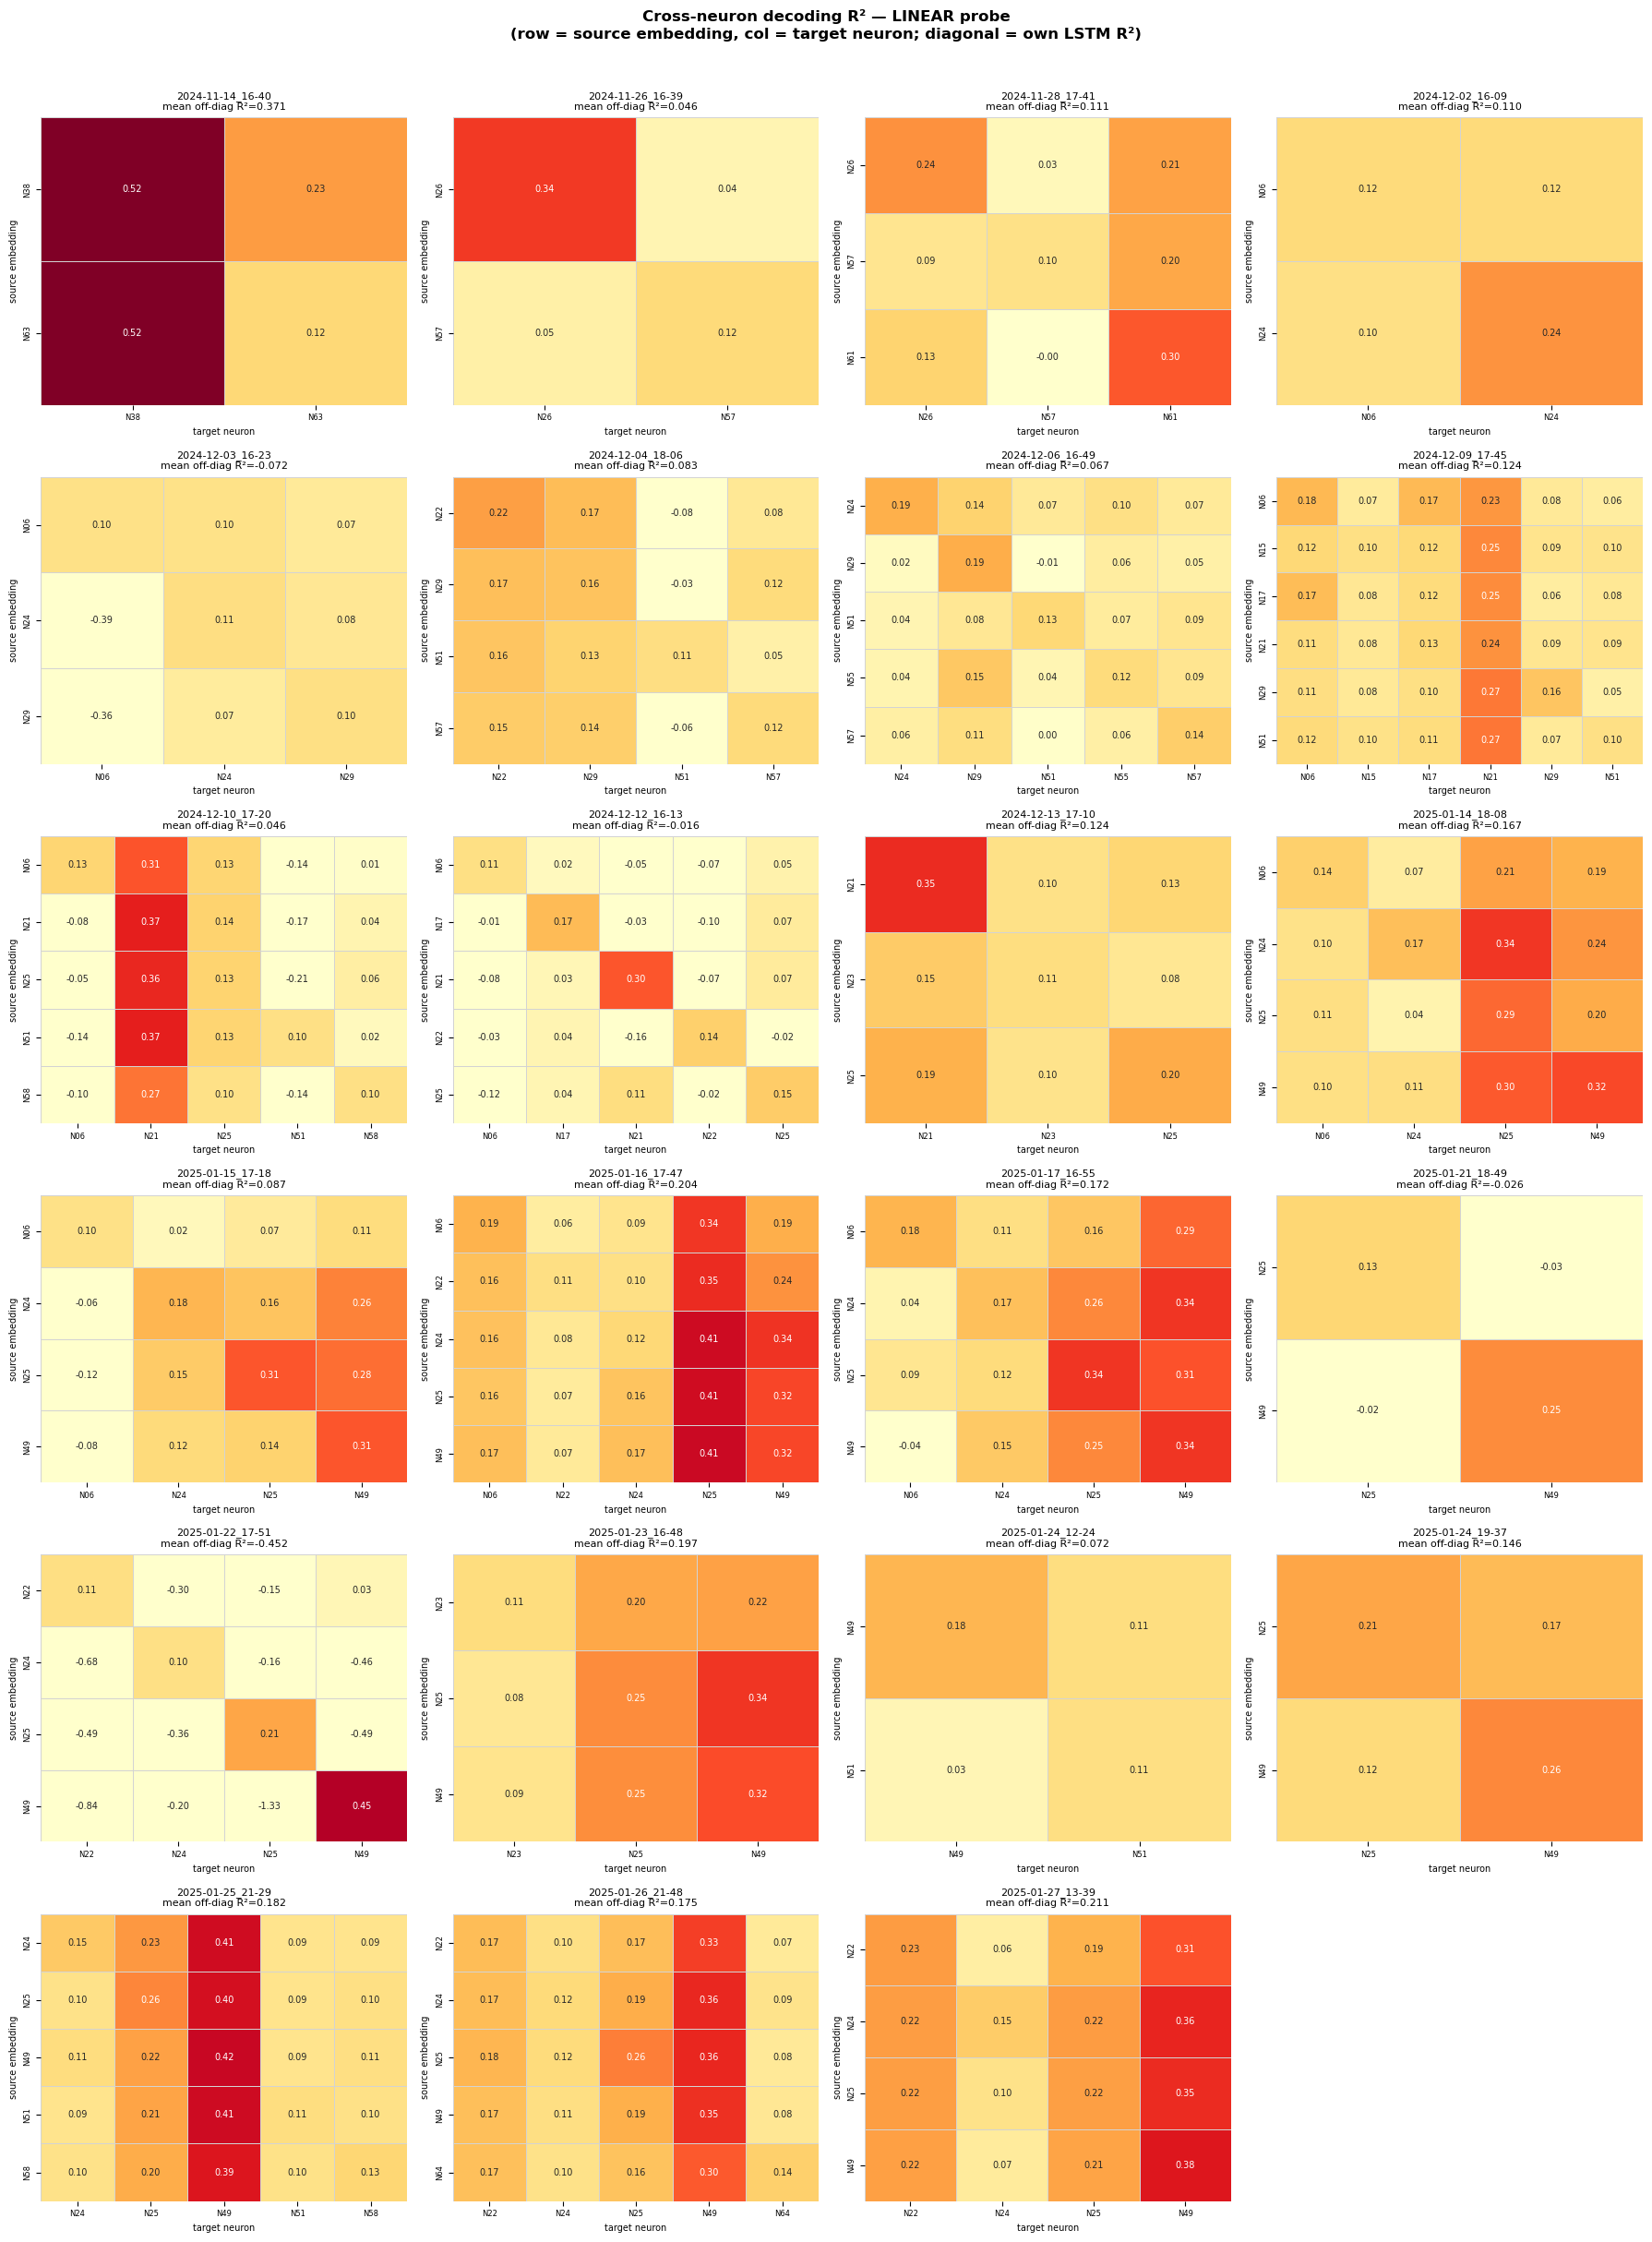

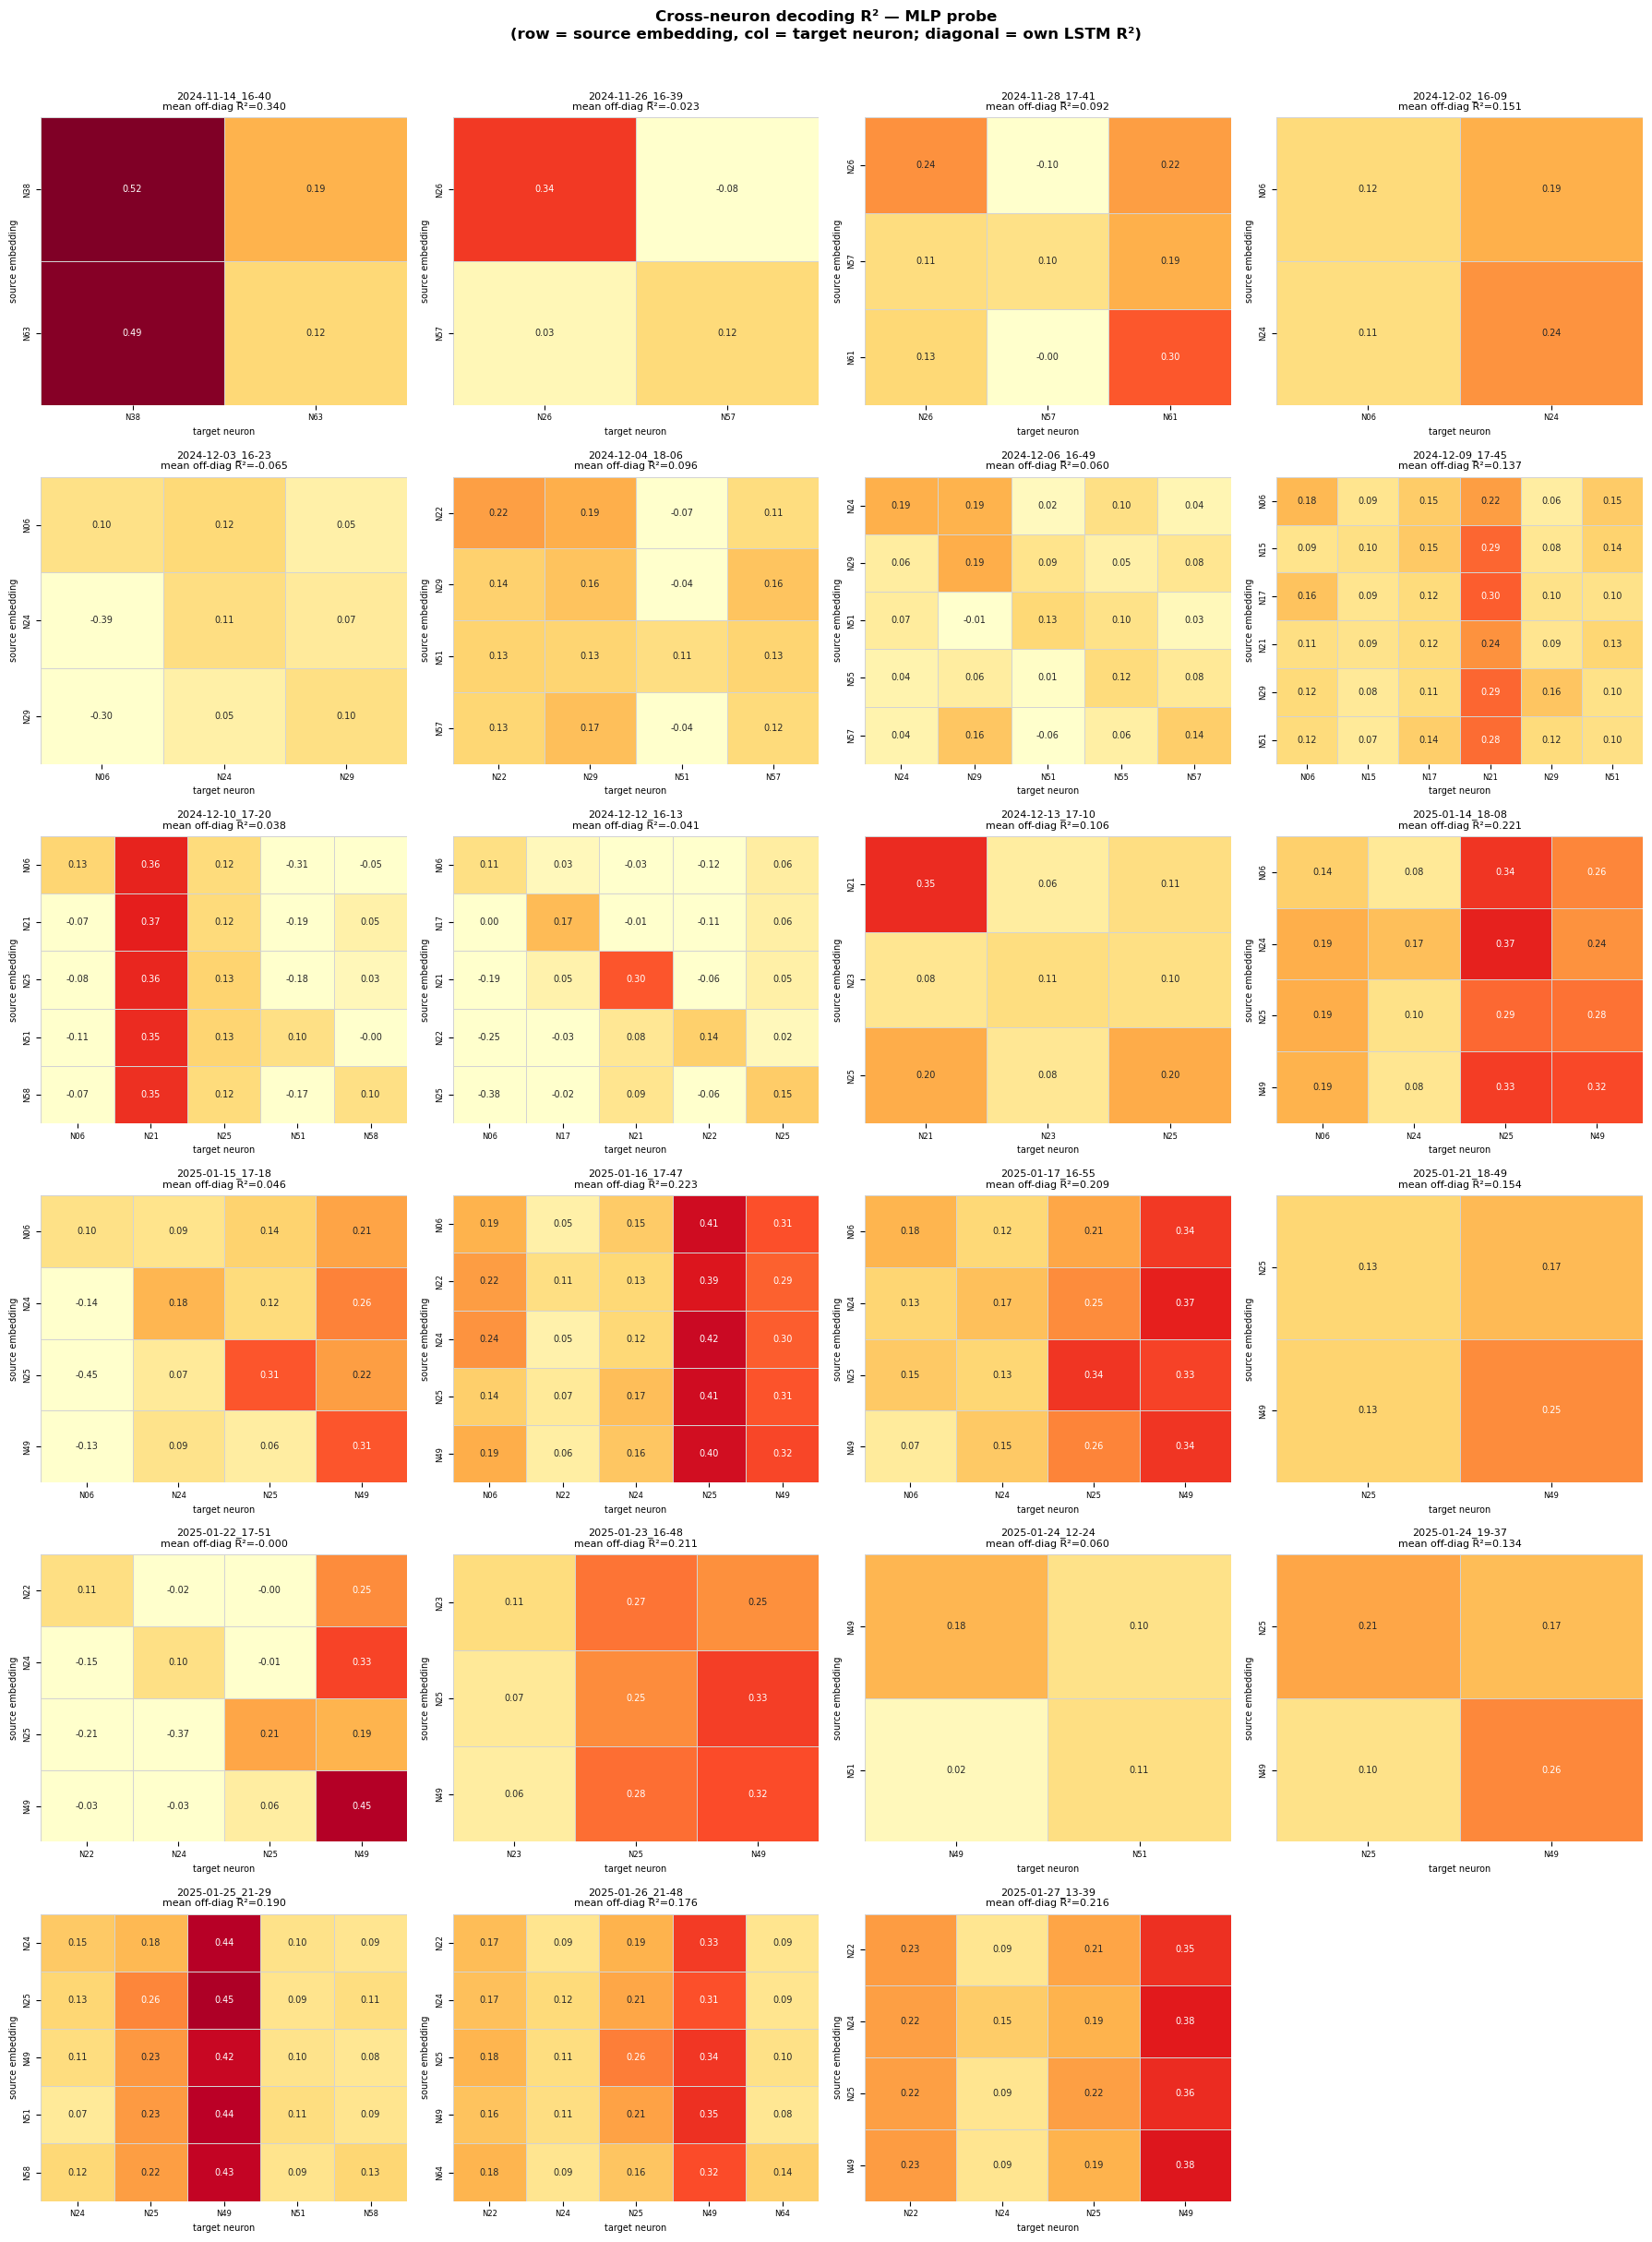

In [29]:
# ── Per-session cross-decode R² heatmaps ─────────────────────────────────────
# Each cell (i→j) = R² from decoding neuron j's firing rate using neuron i's embedding.
# Diagonal is the LSTM's own test R² (from r2_matrix).
# Shows which embedding→neuron pairs carry transferable information.

sessions_to_plot = [sid for sid in session_ids if sid in cross_decode]
ncols = 4
nrows = int(np.ceil(len(sessions_to_plot) / ncols))

for probe_name in ('linear', 'mlp'):
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()

    for ax, sid in zip(axes, sessions_to_plot):
        embs    = embeddings_by_session[sid]
        neurons = sorted(embs.keys())
        k       = len(neurons)
        sess_idx = list(session_ids).index(sid)

        mat = np.full((k, k), np.nan)
        for ii, src in enumerate(neurons):
            # diagonal = own LSTM test R²
            mat[ii, ii] = float(np.clip(r2_clipped[sess_idx, src], 0, 1))
            for jj, tgt in enumerate(neurons):
                if src == tgt:
                    continue
                mat[ii, jj] = cross_decode[sid][(src, tgt)][probe_name]

        labels = [f'N{n+1:02d}' for n in neurons]
        off = mat[~np.eye(k, dtype=bool)]
        sns.heatmap(mat, ax=ax, cmap='YlOrRd', vmin=0, vmax=0.5,
                    xticklabels=labels, yticklabels=labels,
                    cbar=False, linewidths=0.4, linecolor='lightgray',
                    annot=(k <= 6), fmt='.2f', annot_kws={'size': 7})
        ax.set_title(f'{sid}\nmean off-diag R²={np.nanmean(off):.3f}', fontsize=8)
        ax.set_xlabel('target neuron', fontsize=7)
        ax.set_ylabel('source embedding', fontsize=7)
        ax.tick_params(labelsize=6)

    for ax in axes[len(sessions_to_plot):]:
        ax.set_visible(False)

    plt.suptitle(
        f'Cross-neuron decoding R² — {probe_name.upper()} probe\n'
        f'(row = source embedding, col = target neuron; diagonal = own LSTM R²)',
        fontsize=12, fontweight='bold', y=1.01,
    )
    plt.tight_layout()
    plt.show()

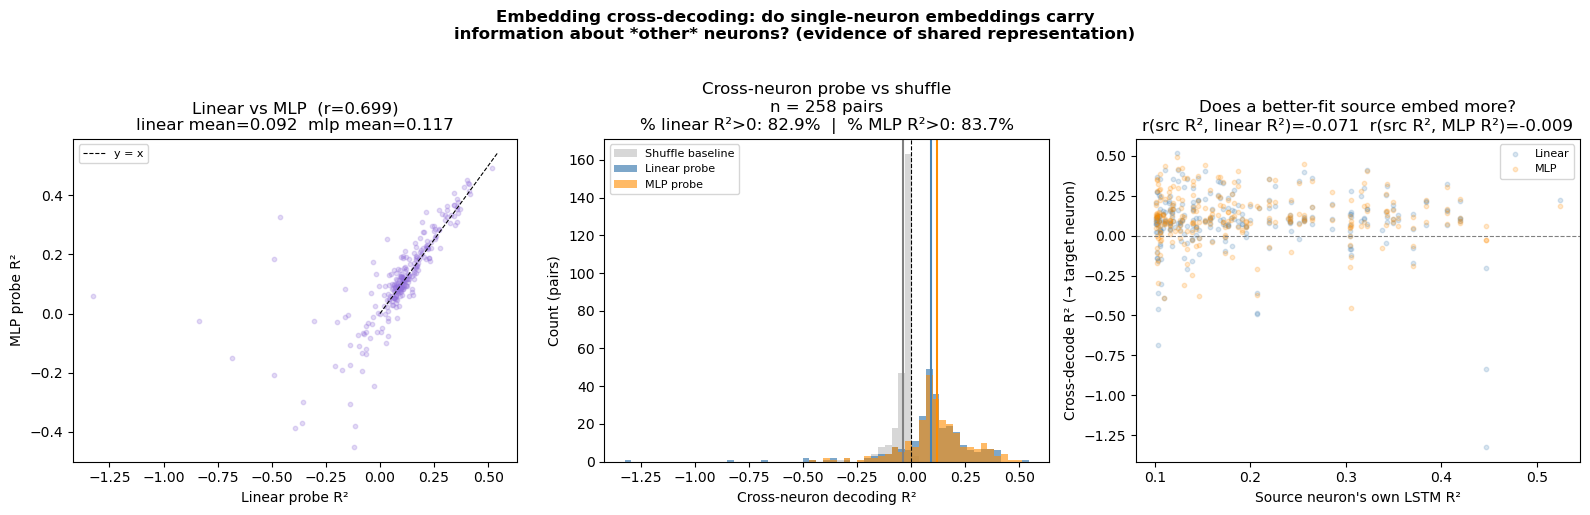

=== Pooled statistics ===
  Shuffle : mean=-0.0392  median=-0.0220  std=0.0504  % > 0 = 2.3%
  Linear  : mean=0.0917  median=0.0999  std=0.1897  % > 0 = 82.9%
  MLP     : mean=0.1169  median=0.1110  std=0.1504  % > 0 = 83.7%


In [30]:
# ── Summary: cross-decode R² vs direct LSTM R², and linear vs MLP vs shuffle ──
# Collects all off-diagonal probe R² values pooled across sessions.

all_lin, all_mlp, all_shuf = [], [], []
all_src_r2, all_tgt_r2     = [], []  # own LSTM R² of source / target neuron

for sess_idx, sid in enumerate(session_ids):
    if sid not in cross_decode:
        continue
    neurons  = sorted(embeddings_by_session[sid].keys())
    sess_r2  = r2_clipped[sess_idx]
    for (src, tgt), v in cross_decode[sid].items():
        all_lin.append(v['linear'])
        all_mlp.append(v['mlp'])
        all_shuf.append(v['shuffle'])
        all_src_r2.append(sess_r2[src])
        all_tgt_r2.append(sess_r2[tgt])

all_lin   = np.array(all_lin)
all_mlp   = np.array(all_mlp)
all_shuf  = np.array(all_shuf)
all_src_r2 = np.array(all_src_r2)
all_tgt_r2 = np.array(all_tgt_r2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── (1) Linear vs MLP probe R² ──────────────────────────────────────────────
ax = axes[0]
lim = max(all_lin.max(), all_mlp.max()) * 1.05
ax.scatter(all_lin, all_mlp, alpha=0.25, s=10, color='mediumpurple', rasterized=True)
ax.plot([0, lim], [0, lim], 'k--', linewidth=0.8, label='y = x')
ax.set_xlabel('Linear probe R²')
ax.set_ylabel('MLP probe R²')
r_lm, _ = pearsonr(all_lin, all_mlp)
ax.set_title(f'Linear vs MLP  (r={r_lm:.3f})\n'
             f'linear mean={all_lin.mean():.3f}  mlp mean={all_mlp.mean():.3f}')
ax.legend(fontsize=8)

# ── (2) Distribution: probe R² vs shuffle ────────────────────────────────────
ax = axes[1]
bins = np.linspace(min(all_shuf.min(), all_lin.min(), -0.05),
                   max(all_lin.max(), all_mlp.max()) * 1.05, 60)
ax.hist(all_shuf, bins=bins, color='lightgray',   edgecolor='none', label='Shuffle baseline', alpha=0.9)
ax.hist(all_lin,  bins=bins, color='steelblue',   edgecolor='none', label='Linear probe',     alpha=0.7)
ax.hist(all_mlp,  bins=bins, color='darkorange',  edgecolor='none', label='MLP probe',        alpha=0.6)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
for val, col, lbl in [(all_shuf.mean(), 'gray', ''), (all_lin.mean(), 'steelblue', ''), (all_mlp.mean(), 'darkorange', '')]:
    ax.axvline(val, color=col, linewidth=1.5)
ax.set_xlabel('Cross-neuron decoding R²')
ax.set_ylabel('Count (pairs)')
ax.set_title(f'Cross-neuron probe vs shuffle\nn = {len(all_lin)} pairs\n'
             f'% linear R²>0: {(all_lin>0).mean()*100:.1f}%  |  '
             f'% MLP R²>0: {(all_mlp>0).mean()*100:.1f}%')
ax.legend(fontsize=8)

# ── (3) Source LSTM R² vs cross-decode R² ────────────────────────────────────
ax = axes[2]
ax.scatter(all_src_r2, all_lin, alpha=0.2, s=10, color='steelblue',
           label='Linear', rasterized=True)
ax.scatter(all_src_r2, all_mlp, alpha=0.2, s=10, color='darkorange',
           label='MLP', rasterized=True)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
r_src_lin, _ = pearsonr(all_src_r2, all_lin)
r_src_mlp, _ = pearsonr(all_src_r2, all_mlp)
ax.set_xlabel("Source neuron's own LSTM R²")
ax.set_ylabel('Cross-decode R² (→ target neuron)')
ax.set_title(f'Does a better-fit source embed more?\n'
             f'r(src R², linear R²)={r_src_lin:.3f}  '
             f'r(src R², MLP R²)={r_src_mlp:.3f}')
ax.legend(fontsize=8)

plt.suptitle('Embedding cross-decoding: do single-neuron embeddings carry\n'
             'information about *other* neurons? (evidence of shared representation)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('=== Pooled statistics ===')
for name, arr in [('Shuffle', all_shuf), ('Linear', all_lin), ('MLP', all_mlp)]:
    print(f'  {name:8s}: mean={arr.mean():.4f}  median={np.median(arr):.4f}  '
          f'std={arr.std():.4f}  % > 0 = {(arr>0).mean()*100:.1f}%')